<a href="https://colab.research.google.com/github/jAgaThasweety/rabacademy/blob/main/rabacadeemy3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload retail-orders-raw.csv


Saving retail-orders-raw.csv to retail-orders-raw (1).csv
EXPLORATORY DATA ANALYSIS

Dataset Shape:
(12, 9)

First 5 Records:


,order_id,order_date,customer_segment,city,category,quantity,unit_price,discount_pct,payment_status
0,RT-1001,2026-01-03,Student,Chennai,Learning Kit,2,799,10.0,Paid
1,RT-1002,03/01/2026,Fresher,Bengaluru,Course Access,1,1499,0.0,paid
2,RT-1003,2026-01-05,student,Chennai,Course Access,1,1499,NaN,Pending
3,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.0,Paid
4,RT-1004,2026-01-07,Professional,Hyderabad,Learning Kit,3,799,5.0,Paid



Columns:
['order_id', 'order_date', 'customer_segment', 'city', 'category', 'quantity', 'unit_price', 'discount_pct', 'payment_status']

Detected Columns
-----------------------------
Order     : order_id
Customer  : None
Quantity  : quantity
Price     : unit_price
Sales     : None
Date      : order_date
Discount  : None
Category  : category

DATA TYPES
order_id             object
order_date           object
customer_segment     object
city                 object
category             object
quantity             object
unit_price            int64
discount_pct        float64
payment_status       object
dtype: object

MISSING VALUES


,Missing Count,Missing %
order_id,0,0.000000
order_date,1,8.333333
customer_segment,0,0.000000
city,1,8.333333
category,0,0.000000
quantity,0,0.000000
unit_price,0,0.000000
discount_pct,1,8.333333
payment_status,0,0.000000



Duplicate Records:
1

DESCRIPTIVE STATISTICS


,Mean,Median,Std Dev,Minimum,Q1,Q3,Maximum
quantity,1.454545,1.0,1.128152,-1.0,1.0,2.0,3.0
unit_price,1082.333333,999.0,318.614425,799.0,799.0,1499.0,1499.0
discount_pct,13.636364,5.0,30.748245,0.0,0.0,10.0,105.0



HISTOGRAM DISTRIBUTIONS


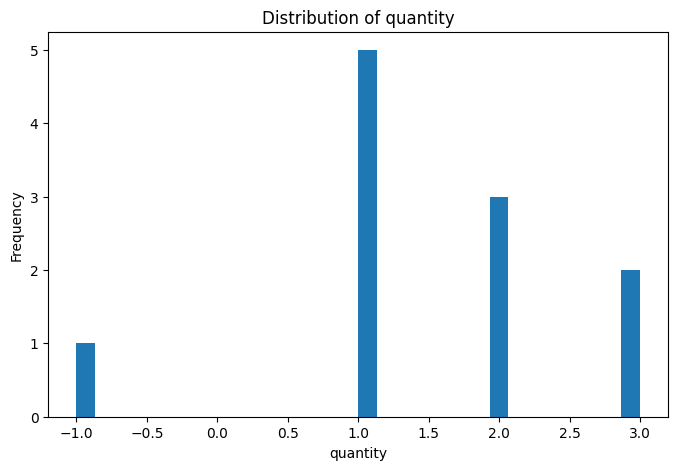

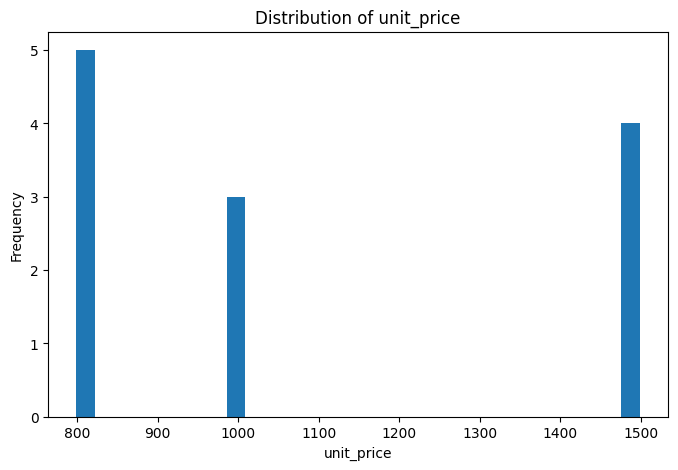

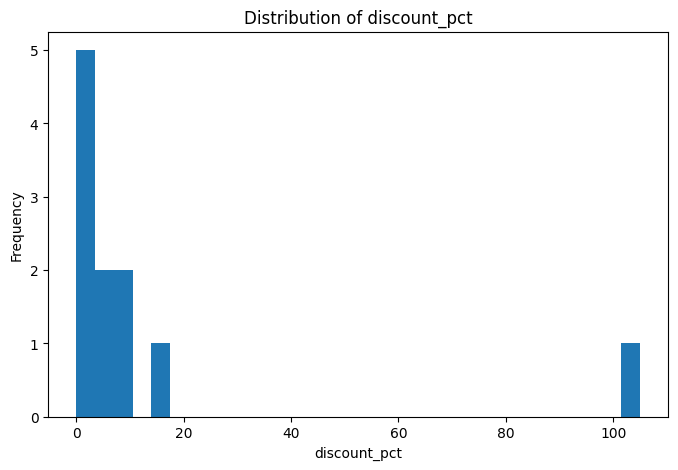


BOX PLOTS


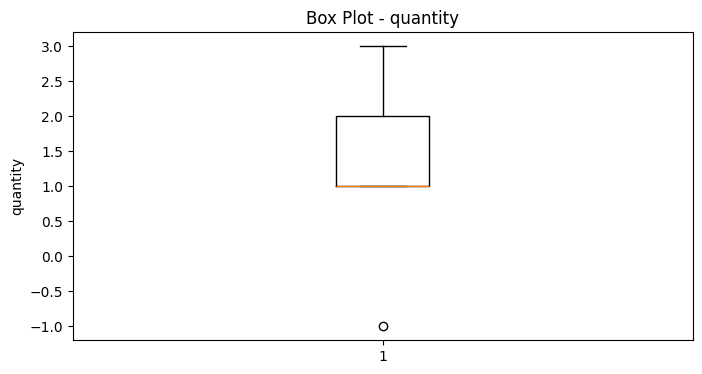

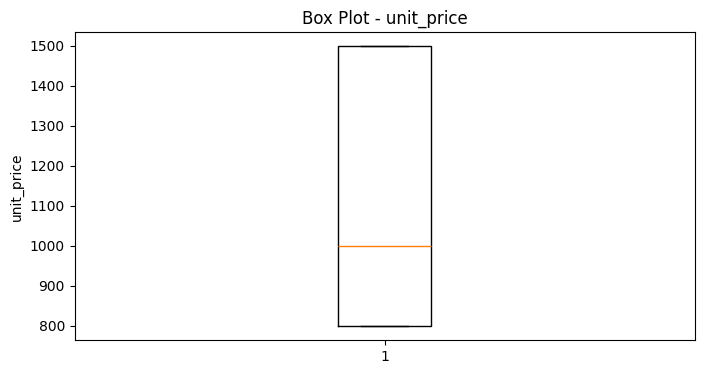

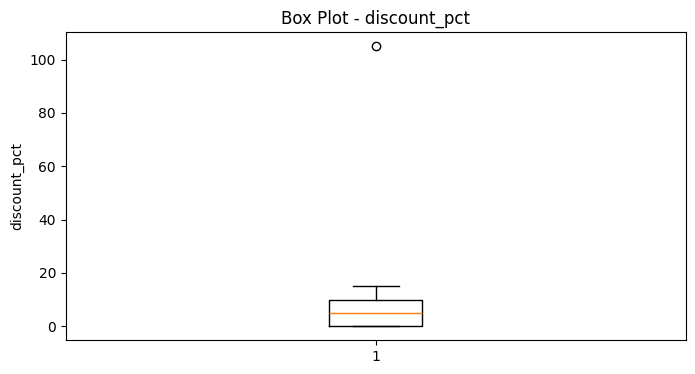


CORRELATION MATRIX


,quantity,unit_price,discount_pct
quantity,1.000000,-0.095266,0.161747
unit_price,-0.095266,1.000000,-0.056799
discount_pct,0.161747,-0.056799,1.000000


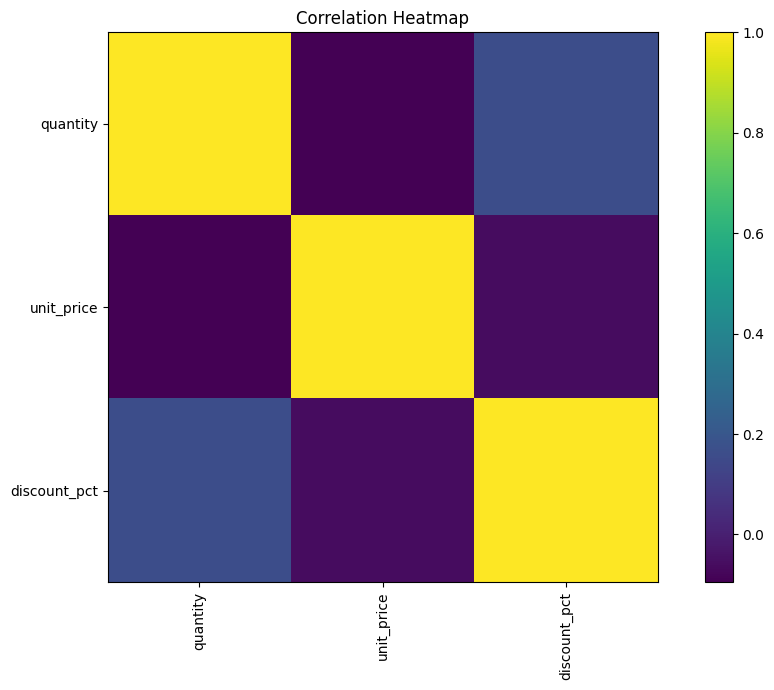


HYPOTHESIS 1

HYPOTHESIS 2

HYPOTHESIS 3

TOP 5 CRITICAL FINDINGS
2. Total quantity sold is 16 units.
4. The dataset contains 11 unique orders.

EDA SUMMARY

## EDA Summary

### Descriptive Statistics
Mean, median, standard deviation, quartiles,
minimum and maximum values were calculated for
the numerical variables.

### Distribution Analysis
Histograms were used to understand the distribution
of numerical business variables.

### Outlier Analysis
Box plots were used to identify unusually high
or low observations.

### Correlation Analysis
A correlation matrix and heatmap were generated
to identify relationships between numerical variables.

### Hypothesis Testing
Three business hypotheses were tested using
Pearson correlation, independent t-test and ANOVA
where the required columns were available.

### Business Interpretation
The statistical results should be interpreted as
associations or differences in the observed data.
Statistical significance does not by itself establish
causati

In [1]:
# ============================================================
# EXPLORATORY DATA ANALYSIS & STATISTICAL INSIGHTS
# Retail Orders Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from google.colab import files

# ------------------------------------------------------------
# 1. UPLOAD DATA
# ------------------------------------------------------------

print("Upload retail-orders-raw.csv")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
display(df.head())


# ------------------------------------------------------------
# 2. STANDARDIZE COLUMN NAMES
# ------------------------------------------------------------

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("\nColumns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 3. AUTOMATIC COLUMN DETECTION
# ------------------------------------------------------------

def find_column(names):

    for name in names:
        if name in df.columns:
            return name

    return None


order_col = find_column([
    "transaction_id",
    "order_id",
    "orderid"
])

customer_col = find_column([
    "customer_id",
    "customerid",
    "customer"
])

quantity_col = find_column([
    "quantity",
    "qty",
    "units"
])

price_col = find_column([
    "price_per_unit",
    "unit_price",
    "price",
    "selling_price"
])

sales_col = find_column([
    "total_spent",
    "total_amount",
    "total",
    "sales",
    "revenue",
    "amount"
])

date_col = find_column([
    "transaction_date",
    "order_date",
    "date"
])

discount_col = find_column([
    "discount",
    "discount_amount",
    "discount_percentage"
])

category_col = find_column([
    "category",
    "product_category"
])


print("\nDetected Columns")
print("-----------------------------")
print("Order     :", order_col)
print("Customer  :", customer_col)
print("Quantity  :", quantity_col)
print("Price     :", price_col)
print("Sales     :", sales_col)
print("Date      :", date_col)
print("Discount  :", discount_col)
print("Category  :", category_col)


# ------------------------------------------------------------
# 4. DATA TYPES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)


# ------------------------------------------------------------
# 5. MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100
})

display(missing)


# ------------------------------------------------------------
# 6. DUPLICATES
# ------------------------------------------------------------

print("\nDuplicate Records:")
print(df.duplicated().sum())


# ------------------------------------------------------------
# 7. CONVERT NUMERIC COLUMNS
# ------------------------------------------------------------

for col in [quantity_col, price_col, sales_col, discount_col]:

    if col is not None:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


# ------------------------------------------------------------
# 8. DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

numeric_df = df.select_dtypes(
    include=np.number
)

statistics = pd.DataFrame({
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Std Dev": numeric_df.std(),
    "Minimum": numeric_df.min(),
    "Q1": numeric_df.quantile(0.25),
    "Q3": numeric_df.quantile(0.75),
    "Maximum": numeric_df.max()
})

display(statistics)


# ------------------------------------------------------------
# 9. HISTOGRAMS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HISTOGRAM DISTRIBUTIONS")
print("=" * 70)

for col in numeric_df.columns:

    plt.figure(figsize=(8, 5))

    plt.hist(
        numeric_df[col].dropna(),
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()


# ------------------------------------------------------------
# 10. BOX PLOTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BOX PLOTS")
print("=" * 70)

for col in numeric_df.columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        numeric_df[col].dropna()
    )

    plt.title(f"Box Plot - {col}")
    plt.ylabel(col)

    plt.show()


# ------------------------------------------------------------
# 11. CORRELATION MATRIX
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)

correlation = numeric_df.corr()

display(correlation)


# ------------------------------------------------------------
# 12. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

plt.imshow(
    correlation,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 13. MULTIVARIATE VISUALIZATION
# ------------------------------------------------------------

if price_col and quantity_col and sales_col:

    plt.figure(figsize=(8, 6))

    plt.scatter(
        df[quantity_col],
        df[sales_col],
        alpha=0.5
    )

    plt.xlabel("Quantity")
    plt.ylabel("Sales")
    plt.title("Quantity vs Sales")

    plt.show()


# ------------------------------------------------------------
# 14. BUSINESS HYPOTHESIS 1
# ------------------------------------------------------------
# H1:
# Higher quantity is associated with higher sales.

print("\n" + "=" * 70)
print("HYPOTHESIS 1")
print("=" * 70)

if quantity_col and sales_col:

    temp = df[
        [quantity_col, sales_col]
    ].dropna()

    r, p = stats.pearsonr(
        temp[quantity_col],
        temp[sales_col]
    )

    print("H0: Quantity and sales are not significantly correlated.")
    print("H1: Quantity and sales are significantly correlated.")

    print(f"\nCorrelation: {r:.4f}")
    print(f"P-value: {p:.6f}")

    if p < 0.05:
        print("Result: Statistically significant relationship.")
    else:
        print("Result: No statistically significant relationship.")


# ------------------------------------------------------------
# 15. BUSINESS HYPOTHESIS 2
# ------------------------------------------------------------
# H2:
# Orders with discounts have different sales than
# orders without discounts.

print("\n" + "=" * 70)
print("HYPOTHESIS 2")
print("=" * 70)

if discount_col and sales_col:

    temp = df[
        [discount_col, sales_col]
    ].dropna()

    discounted = temp[
        temp[discount_col] > 0
    ][sales_col]

    non_discounted = temp[
        temp[discount_col] == 0
    ][sales_col]

    if len(discounted) > 1 and len(non_discounted) > 1:

        t_stat, p = stats.ttest_ind(
            discounted,
            non_discounted,
            equal_var=False
        )

        print(
            "H0: Mean sales are the same for discounted "
            "and non-discounted orders."
        )

        print(
            "H1: Mean sales differ between discounted "
            "and non-discounted orders."
        )

        print("\nDiscounted Mean Sales:",
              discounted.mean())

        print("Non-discounted Mean Sales:",
              non_discounted.mean())

        print(f"\nT-statistic: {t_stat:.4f}")
        print(f"P-value: {p:.6f}")

        if p < 0.05:
            print(
                "Result: Statistically significant difference."
            )
        else:
            print(
                "Result: No statistically significant difference."
            )


# ------------------------------------------------------------
# 16. BUSINESS HYPOTHESIS 3
# ------------------------------------------------------------
# H3:
# Sales differ across product categories.

print("\n" + "=" * 70)
print("HYPOTHESIS 3")
print("=" * 70)

if category_col and sales_col:

    category_data = []

    categories = (
        df[category_col]
        .dropna()
        .unique()
    )

    for category in categories:

        values = df[
            df[category_col] == category
        ][sales_col].dropna()

        if len(values) >= 2:

            category_data.append(values)

    if len(category_data) >= 2:

        f_stat, p = stats.f_oneway(
            *category_data
        )

        print(
            "H0: Mean sales are equal across categories."
        )

        print(
            "H1: At least one category has a different "
            "mean sales value."
        )

        print(f"\nF-statistic: {f_stat:.4f}")
        print(f"P-value: {p:.6f}")

        if p < 0.05:
            print(
                "Result: Significant difference among categories."
            )
        else:
            print(
                "Result: No statistically significant difference."
            )


# ------------------------------------------------------------
# 17. TOP 5 BUSINESS FINDINGS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP 5 CRITICAL FINDINGS")
print("=" * 70)

findings = []

# Finding 1
if sales_col:

    findings.append(
        f"1. Total sales in the dataset are "
        f"{df[sales_col].sum():,.2f}."
    )

# Finding 2
if quantity_col:

    findings.append(
        f"2. Total quantity sold is "
        f"{df[quantity_col].sum():,.0f} units."
    )

# Finding 3
if customer_col:

    findings.append(
        f"3. The dataset contains "
        f"{df[customer_col].nunique():,} unique customers."
    )

# Finding 4
if order_col:

    findings.append(
        f"4. The dataset contains "
        f"{df[order_col].nunique():,} unique orders."
    )

# Finding 5
if sales_col:

    highest_sales_column = (
        df[sales_col]
        .dropna()
    )

    if len(highest_sales_column) > 0:

        findings.append(
            f"5. Average transaction sales are "
            f"{highest_sales_column.mean():,.2f}."
        )


for finding in findings[:5]:
    print(finding)


# ------------------------------------------------------------
# 18. MARKDOWN-STYLE SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EDA SUMMARY")
print("=" * 70)

print("""
## EDA Summary

### Descriptive Statistics
Mean, median, standard deviation, quartiles,
minimum and maximum values were calculated for
the numerical variables.

### Distribution Analysis
Histograms were used to understand the distribution
of numerical business variables.

### Outlier Analysis
Box plots were used to identify unusually high
or low observations.

### Correlation Analysis
A correlation matrix and heatmap were generated
to identify relationships between numerical variables.

### Hypothesis Testing
Three business hypotheses were tested using
Pearson correlation, independent t-test and ANOVA
where the required columns were available.

### Business Interpretation
The statistical results should be interpreted as
associations or differences in the observed data.
Statistical significance does not by itself establish
causation.
""")


# ------------------------------------------------------------
# 19. SAVE ANALYSIS DATA
# ------------------------------------------------------------

df.to_csv(
    "eda_prepared_dataset.csv",
    index=False
)

print("\nAnalysis completed successfully!")

print("\nFiles:")
print("✓ EDA_Statistical_Insights.ipynb")
print("✓ Analysis results displayed above")